## Mapa das zonas de Aveiro que vamos usar na análise

C:\Users\gabri\AppData\Local\Temp\ipykernel_21792\1146335429.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  freguesias.intersects(concelho.unary_union) &


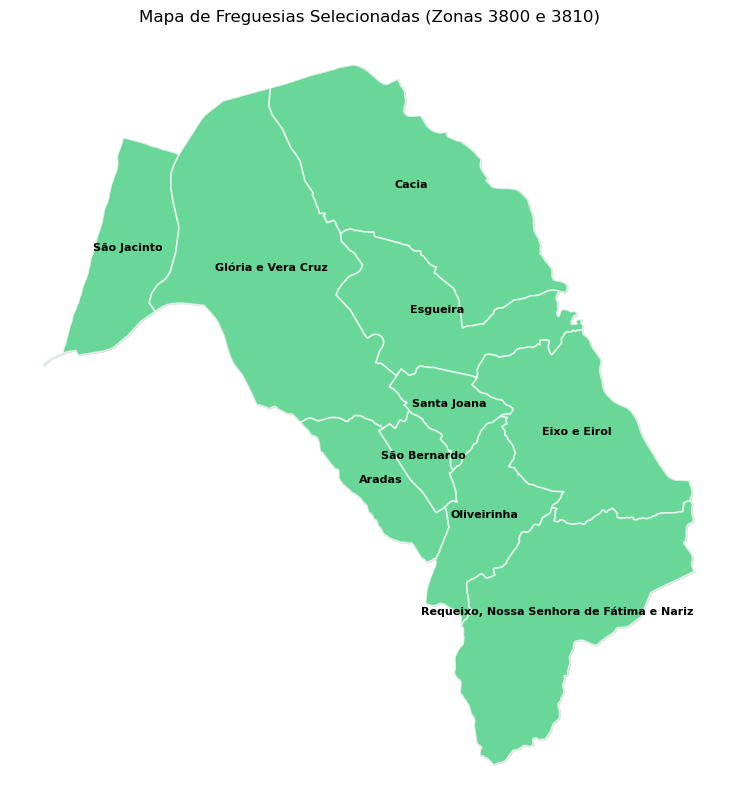

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt

# 1. Obter o limite do concelho e freguesias
concelho = ox.geocode_to_gdf("Aveiro, Portugal")
freguesias = ox.features_from_place("Aveiro, Portugal", tags={"admin_level": "8"})

# 2. Lista atualizada com as freguesias que pediste
# Adicionei São Jacinto, Oliveirinha e a união de Eixo e Eirol
zonas_alvo = [
    "Esgueira", "Cacia", "Aradas", "São Bernardo", 
    "Santa Joana", "Glória e Vera Cruz", "Oliveirinha", 
    "São Jacinto", "Eixo e Eirol" , "Requeixo"
]

# 3. Filtrar
mapa_filtrado = freguesias[
    freguesias.intersects(concelho.unary_union) & 
    (freguesias['name'].str.contains('|'.join(zonas_alvo), case=False, na=False))
]

# 4. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 10))

# Aveiro completo em cinza claro para contexto
concelho.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', zorder=1)

# As tuas zonas em destaque (agora incluindo São Jacinto e o interior)
mapa_filtrado.plot(
    ax=ax, 
    facecolor="#2ecc71", # Cor verde suave para diferenciar
    edgecolor="white", 
    linewidth=1.2, 
    alpha=0.7, 
    zorder=2
)

# 5. Etiquetas
for idx, row in mapa_filtrado.iterrows():
    nome = row['name'].replace('União das freguesias de ', 'U.F. ')
    coords = row.geometry.centroid.coords[0]
    ax.annotate(text=nome, xy=coords, horizontalalignment='center', fontsize=8, fontweight='bold')

plt.title("Mapa de Freguesias Selecionadas (Zonas 3800 e 3810)")
plt.axis("off")
plt.show()

## Evolução temporal do consumo elétrico em Aveiro no mês de Fevereiro de 2024

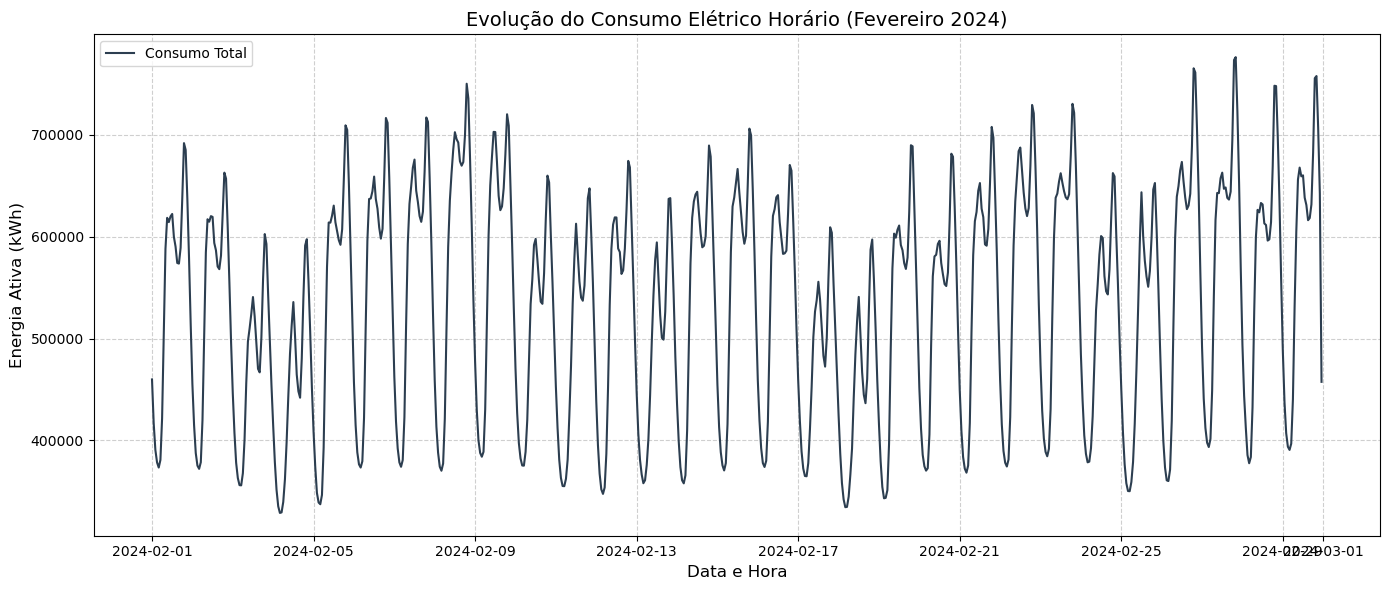

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar os dados (ajuste o nome do ficheiro se necessário)
df = pd.read_csv(r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Milestone2\raw\consumoshorariocodigopostal3781a4420.csv", sep=';')

# 2. Converter a coluna de tempo para formato datetime
df['Data/Hora'] = pd.to_datetime(df['Data/Hora'])

# 3. Agrupar o consumo por hora (somando todos os códigos postais)
# Isso permite ver a carga total da rede em cada momento
hourly_consumption = df.groupby('Data/Hora')['Energia ativa (kWh)'].sum().reset_index()

# 4. Ordenar cronologicamente
hourly_consumption = hourly_consumption.sort_values('Data/Hora')

# 5. Criar o gráfico
plt.figure(figsize=(14, 6))
plt.plot(hourly_consumption['Data/Hora'], hourly_consumption['Energia ativa (kWh)'], 
         color='#2c3e50', linewidth=1.5, label='Consumo Total')

# Configurações visuais
plt.title('Evolução do Consumo Elétrico Horário (Fevereiro 2024)', fontsize=14)
plt.xlabel('Data e Hora', fontsize=12)
plt.ylabel('Energia Ativa (kWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Ajustar o layout e mostrar
plt.tight_layout()
plt.show()

## Evolução temporal com interação para ver as horas

In [4]:
import plotly.express as px

fig = px.line(hourly_consumption, x='Data/Hora', y='Energia ativa (kWh)', 
              title='Consumo Horário - Passe o rato para ver a hora')
fig.show()